<a href="https://colab.research.google.com/github/ignaciomorenobarria21-a11y/Machine_Learning/blob/main/Sesion_08_Particion_IS_OOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Fundamentos de Machine Learning

## Sesión 8: Partición In-Sample / Out-of-Sample

**Máster en Formación Permanente en Inteligencia Artificial para el Sector Financiero**  
Universidad Internacional de Valencia · Edición Octubre 2025/26

---

📅 **Fecha:** 3 de febrero de 2026  
⏱️ **Duración:** ~100 minutos  
👨‍🏫 **Profesor:** Jaume Antolí Plaza

## 1. Introducción: El Error que Hemos Cometido

En las sesiones anteriores hemos entrenado y evaluado nuestros modelos **con los mismos datos**. Esto nos ha dado resultados **optimistas pero irreales**.

```
LO QUE HEMOS HECHO HASTA AHORA (MAL)
═══════════════════════════════════════════════════════════════════

    Dataset completo 2010-2019
    ┌─────────────────────────────────────────────────────────────┐
    │  ████████████████████████████████████████████████████████   │
    │                                                             │
    │              TRAIN + TEST (mismos datos)                    │
    │                                                             │
    └─────────────────────────────────────────────────────────────┘
    
    → El modelo "memoriza" los datos
    → Accuracy alto pero FALSO
    → No sabemos cómo funcionará en datos nuevos
    → Las curvas de equity son FANTASÍA


LO QUE DEBERÍAMOS HACER (BIEN)
═══════════════════════════════════════════════════════════════════

    Dataset completo 2010-2019
    ┌─────────────────────────────────────────┬───────────────────┐
    │  ██████████████████████████████████████ │ ░░░░░░░░░░░░░░░░░ │
    │                                         │                   │
    │         IN-SAMPLE (IS)                  │  OUT-OF-SAMPLE    │
    │         Entrenamiento                   │      (OOS)        │
    │         + Selección features            │      Test         │
    │                                         │   DATOS NUEVOS    │
    └─────────────────────────────────────────┴───────────────────┘
    
    → El modelo NUNCA ve los datos OOS durante el entrenamiento
    → Evaluación HONESTA del rendimiento real
    → Las curvas de equity OOS son REALISTAS
```

### ¿Por Qué Es Crucial en Trading?

```
EN TRADING, EL OOS ES TU DINERO REAL
═══════════════════════════════════════════════════════════════════

    Fase de desarrollo          │  Fase de producción
    (puedes equivocarte)        │  (cada error = pérdida real)
                                │
    ┌───────────────────────────┼───────────────────────────────┐
    │                           │                               │
    │   Datos históricos        │   Datos futuros               │
    │   IS: entrenas            │   Trading real                │
    │   OOS: simulas            │   Dinero real                 │
    │                           │                               │
    └───────────────────────────┼───────────────────────────────┘
                                │
                              HOY
    
    El OOS es nuestra MEJOR ESTIMACIÓN de cómo funcionará
    el modelo cuando lo pongamos en producción.
    
    Si el OOS miente → Pérdidas reales garantizadas
```

## 2. División Temporal: No Mezclar Pasado con Futuro

En series temporales financieras, la división **DEBE** respetar el orden cronológico.

```
DIVISIÓN ALEATORIA (train_test_split con shuffle=True)
═══════════════════════════════════════════════════════════════════

    Tiempo →  2010   2011   2012   2013   2014   2015   2016   2017
              ─────────────────────────────────────────────────────
              Train  TEST   Train  TEST   Train  Train  TEST   Train
                ↓      ↑       ↓      ↑
                └──────┘       └──────┘
                 FUTURO         FUTURO
                predice        predice
                 PASADO         PASADO
    
    ⚠️ LOOK-AHEAD BIAS: Usamos información del futuro para predecir el pasado
    ⚠️ El modelo "sabe" cosas que no podría saber en tiempo real
    ⚠️ Resultados COMPLETAMENTE irreales


DIVISIÓN TEMPORAL (CORRECTA para series financieras)
═══════════════════════════════════════════════════════════════════

    Tiempo →  2010   2011   2012   2013   2014   2015   2016   2017
              ─────────────────────────────────────────────────────
              Train  Train  Train  Train  Train  Train  TEST   TEST
                                                   │
                                                   │
                                              Punto de corte
    
    ✅ Siempre entrenamos con PASADO
    ✅ Siempre testeamos con FUTURO
    ✅ Simula condiciones reales de trading
```

### Nuestro Plan para Esta Sesión

```
DISEÑO EXPERIMENTAL
═══════════════════════════════════════════════════════════════════

    Dataset: 2010-2019 (10 años)
    
    Reservamos 2019 como FORWARD TEST (simula trading real)
    
    ┌─────────────────────────────────────────────────┬───────────┐
    │                                                 │           │
    │            2010 ─────────────── 2018            │   2019    │
    │                                                 │           │
    │            Disponible para entrenar             │  FORWARD  │
    │                                                 │   TEST    │
    │            (experimentaremos aquí)              │  (fijo)   │
    │                                                 │           │
    └─────────────────────────────────────────────────┴───────────┘
    
    
    EXPERIMENTO 1: ¿Más histórico = mejor modelo?
    ─────────────────────────────────────────────
    
    Train 2010-2018 (9 años) → Test 2019
    Train 2011-2018 (8 años) → Test 2019
    Train 2012-2018 (7 años) → Test 2019
    Train 2013-2018 (6 años) → Test 2019
    Train 2014-2018 (5 años) → Test 2019
    Train 2015-2018 (4 años) → Test 2019
    Train 2016-2018 (3 años) → Test 2019
    
    
    EXPERIMENTO 2: ¿Datos recientes o lejanos?
    ─────────────────────────────────────────────
    
    Train 2016-2018 (3 años recientes) → Test 2019
    Train 2013-2015 (3 años lejanos)   → Test 2019
```

## 3. Concept Drift: Por Qué los Mercados Cambian

El **concept drift** es el cambio gradual en las relaciones estadísticas que el modelo intenta aprender.

```
CONCEPT DRIFT EN MERCADOS FINANCIEROS
═══════════════════════════════════════════════════════════════════

    Los mercados NO son estacionarios. Cambian por:
    
    • Cambios en participantes (más algoritmos, menos humanos)
    • Cambios regulatorios
    • Cambios macroeconómicos (tipos de interés, inflación)
    • Cambios tecnológicos (HFT, acceso a información)
    • Cambios en correlaciones entre activos
    
    
    Patrón que funcionaba en 2010:
    
        RSI < 30 → Comprar → Beneficio
    
    
    El mismo patrón en 2019:
    
        RSI < 30 → Comprar → ¿Beneficio? ¿Pérdida? ¿Neutral?
        
        (Depende de si el mercado sigue comportándose igual)


VIGENCIA DEL MODELO
═══════════════════════════════════════════════════════════════════

    El modelo tiene MÁXIMA VIGENCIA justo al terminar el entrenamiento.
    Después, va "envejeciendo" por el concept drift.
    
    Vigencia
       ↑
    100%│●
       │ ╲
       │  ╲
       │   ╲
       │    ╲
       │     ╲
       │      ╲
       │       ╲_______________
       │
       └──────────────────────────→ Tiempo
         Fin      Meses    Años
        Train    después  después
    
    
    IMPLICACIÓN CRÍTICA:
    ────────────────────
    
    Si entrenamos con datos LEJANOS y testeamos con datos RECIENTES,
    el modelo ya está "viejo" cuando llega al test.
    
    Peor aún: si el test está ENTRE el train y el forward real,
    el modelo llega al forward todavía más degradado.
```

## 4. Enfoque Tradicional vs Enfoque Trading

```
ENFOQUE TRADICIONAL DE ML (subóptimo para trading)
═══════════════════════════════════════════════════════════════════

    "Usa el máximo histórico posible, 70% train, 30% test"
    
    2010          2016    2017    2018    2019     Futuro
    ├──────────────┼───────┼───────┼───────┼────────────────►
    │              │       │       │       │
    │    TRAIN     │       TEST    │       │   FORWARD REAL
    │   (70%)      │      (30%)    │       │   (trading)
    │              │               │       │
    └──────────────┴───────────────┴───────┴────────────────►
                                           │
                                           │
                              El modelo "envejece" durante
                              el test y llega degradado
                              al forward real


ENFOQUE OPTIMIZADO PARA TRADING
═══════════════════════════════════════════════════════════════════

    "Entrena con datos RECIENTES, minimiza gap hasta aplicación"
    
    2010          2016    2017    2018    2019     Futuro
    ├──────────────┼───────┼───────┼───────┼────────────────►
    │              │       │       │       │
    │  (no usado)  │     TRAIN     │  OOS  │   FORWARD REAL
    │              │    (reciente) │       │   (trading)
    │              │               │       │
    └──────────────┴───────────────┴───────┴────────────────►
                                           │
                                           │
                              El modelo llega "fresco"
                              al forward real
    
    
    CLAVE: El OOS (2019) simula el forward real.
           Queremos que el modelo funcione bien en 2019,
           no que tenga buen accuracy en datos de 2012.
```

## 5. Cargar Librerías y Datos

In [ ]:
# ============================================================
# IMPORTAR LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Mostrar todas las columnas en pandas
pd.set_option('display.max_columns', None)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [ ]:
# ============================================================
# CARGA DE DATOS
# Dataset preparado en la Sesión 1 con indicadores técnicos
# ============================================================

# Cargar el dataset directamente desde Google Drive
url = 'https://drive.google.com/uc?id=13vNdqTBl4xZurr1jbcoVHCy9PinJosiL'
df = pd.read_csv(url, index_col=0, parse_dates=True)

print(f"Dataset cargado: {len(df):,} filas")
print(f"Período: {df.index[0].strftime('%Y-%m-%d')} a {df.index[-1].strftime('%Y-%m-%d')}")
print(f"Columnas totales: {len(df.columns)}")
df.head()

Dataset cargado: 2,489 filas
Período: 2010-05-25 a 2019-12-30
Columnas totales: 501


,Open,High,Low,Close,RSI_2,STOCH_2,WILLR_2,CCI_2,ADX_2,RSI_3,STOCH_3,WILLR_3,CCI_3,ADX_3,RSI_4,STOCH_4,WILLR_4,CCI_4,ADX_4,RSI_5,STOCH_5,WILLR_5,CCI_5,ADX_5,RSI_6,STOCH_6,WILLR_6,CCI_6,ADX_6,RSI_7,STOCH_7,WILLR_7,CCI_7,ADX_7,RSI_8,STOCH_8,WILLR_8,CCI_8,ADX_8,RSI_9,STOCH_9,WILLR_9,CCI_9,ADX_9,RSI_10,STOCH_10,WILLR_10,CCI_10,ADX_10,RSI_11,STOCH_11,WILLR_11,CCI_11,ADX_11,RSI_12,STOCH_12,WILLR_12,CCI_12,ADX_12,RSI_13,STOCH_13,WILLR_13,CCI_13,ADX_13,RSI_14,STOCH_14,WILLR_14,CCI_14,ADX_14,RSI_15,STOCH_15,WILLR_15,CCI_15,ADX_15,RSI_16,STOCH_16,WILLR_16,CCI_16,ADX_16,RSI_17,STOCH_17,WILLR_17,CCI_17,ADX_17,RSI_18,STOCH_18,WILLR_18,CCI_18,ADX_18,RSI_19,STOCH_19,WILLR_19,CCI_19,ADX_19,RSI_20,STOCH_20,WILLR_20,CCI_20,ADX_20,RSI_21,STOCH_21,WILLR_21,CCI_21,ADX_21,RSI_22,STOCH_22,WILLR_22,CCI_22,ADX_22,RSI_23,STOCH_23,WILLR_23,CCI_23,ADX_23,RSI_24,STOCH_24,WILLR_24,CCI_24,ADX_24,RSI_25,STOCH_25,WILLR_25,CCI_25,ADX_25,RSI_26,STOCH_26,WILLR_26,CCI_26,ADX_26,RSI_27,STOCH_27,WILLR_27,CCI_27,ADX_27,RSI_28,STOCH_28,WILLR_28,CCI_28,ADX_28,RSI_29,STOCH_29,WILLR_29,CCI_29,ADX_29,RSI_30,STOCH_30,WILLR_30,CCI_30,ADX_30,RSI_31,STOCH_31,WILLR_31,CCI_31,ADX_31,RSI_32,STOCH_32,WILLR_32,CCI_32,ADX_32,RSI_33,STOCH_33,WILLR_33,CCI_33,ADX_33,RSI_34,STOCH_34,WILLR_34,CCI_34,ADX_34,RSI_35,STOCH_35,WILLR_35,CCI_35,ADX_35,RSI_36,STOCH_36,WILLR_36,CCI_36,ADX_36,RSI_37,STOCH_37,WILLR_37,CCI_37,ADX_37,RSI_38,STOCH_38,WILLR_38,CCI_38,ADX_38,RSI_39,STOCH_39,WILLR_39,CCI_39,ADX_39,RSI_40,STOCH_40,WILLR_40,CCI_40,ADX_40,RSI_41,STOCH_41,WILLR_41,CCI_41,ADX_41,RSI_42,STOCH_42,WILLR_42,CCI_42,ADX_42,RSI_43,STOCH_43,WILLR_43,CCI_43,ADX_43,RSI_44,STOCH_44,WILLR_44,CCI_44,ADX_44,RSI_45,STOCH_45,WILLR_45,CCI_45,ADX_45,RSI_46,STOCH_46,WILLR_46,CCI_46,ADX_46,RSI_47,STOCH_47,WILLR_47,CCI_47,ADX_47,RSI_48,STOCH_48,WILLR_48,CCI_48,ADX_48,RSI_49,STOCH_49,WILLR_49,CCI_49,ADX_49,RSI_50,STOCH_50,WILLR_50,CCI_50,ADX_50,RSI_51,STOCH_51,WILLR_51,CCI_51,ADX_51,RSI_52,STOCH_52,WILLR_52,CCI_52,ADX_52,RSI_53,STOCH_53,WILLR_53,CCI_53,ADX_53,RSI_54,STOCH_54,WILLR_54,CCI_54,ADX_54,RSI_55,STOCH_55,WILLR_55,CCI_55,ADX_55,RSI_56,STOCH_56,WILLR_56,CCI_56,ADX_56,RSI_57,STOCH_57,WILLR_57,CCI_57,ADX_57,RSI_58,STOCH_58,WILLR_58,CCI_58,ADX_58,RSI_59,STOCH_59,WILLR_59,CCI_59,ADX_59,RSI_60,STOCH_60,WILLR_60,CCI_60,ADX_60,RSI_61,STOCH_61,WILLR_61,CCI_61,ADX_61,RSI_62,STOCH_62,WILLR_62,CCI_62,ADX_62,RSI_63,STOCH_63,WILLR_63,CCI_63,ADX_63,RSI_64,STOCH_64,WILLR_64,CCI_64,ADX_64,RSI_65,STOCH_65,WILLR_65,CCI_65,ADX_65,RSI_66,STOCH_66,WILLR_66,CCI_66,ADX_66,RSI_67,STOCH_67,WILLR_67,CCI_67,ADX_67,RSI_68,STOCH_68,WILLR_68,CCI_68,ADX_68,RSI_69,STOCH_69,WILLR_69,CCI_69,ADX_69,RSI_70,STOCH_70,WILLR_70,CCI_70,ADX_70,RSI_71,STOCH_71,WILLR_71,CCI_71,ADX_71,RSI_72,STOCH_72,WILLR_72,CCI_72,ADX_72,RSI_73,STOCH_73,WILLR_73,CCI_73,ADX_73,RSI_74,STOCH_74,WILLR_74,CCI_74,ADX_74,RSI_75,STOCH_75,WILLR_75,CCI_75,ADX_75,RSI_76,STOCH_76,WILLR_76,CCI_76,ADX_76,RSI_77,STOCH_77,WILLR_77,CCI_77,ADX_77,RSI_78,STOCH_78,WILLR_78,CCI_78,ADX_78,RSI_79,STOCH_79,WILLR_79,CCI_79,ADX_79,RSI_80,STOCH_80,WILLR_80,CCI_80,ADX_80,RSI_81,STOCH_81,WILLR_81,CCI_81,ADX_81,RSI_82,STOCH_82,WILLR_82,CCI_82,ADX_82,RSI_83,STOCH_83,WILLR_83,CCI_83,ADX_83,RSI_84,STOCH_84,WILLR_84,CCI_84,ADX_84,RSI_85,STOCH_85,WILLR_85,CCI_85,ADX_85,RSI_86,STOCH_86,WILLR_86,CCI_86,ADX_86,RSI_87,STOCH_87,WILLR_87,CCI_87,ADX_87,RSI_88,STOCH_88,WILLR_88,CCI_88,ADX_88,RSI_89,STOCH_89,WILLR_89,CCI_89,ADX_89,RSI_90,STOCH_90,WILLR_90,CCI_90,ADX_90,RSI_91,STOCH_91,WILLR_91,CCI_91,ADX_91,RSI_92,STOCH_92,WILLR_92,CCI_92,ADX_92,RSI_93,STOCH_93,WILLR_93,CCI_93,ADX_93,RSI_94,STOCH_94,WILLR_94,CCI_94,ADX_94,RSI_95,STOCH_95,WILLR_95,CCI_95,ADX_95,RSI_96,STOCH_96,WILLR_96,CCI_96,ADX_96,RSI_97,STOCH_97,WILLR_97,CCI_97,ADX_97,RSI_98,STOCH_98,WILLR_98,CCI_98,ADX_98,RSI_99,STOCH_99,WILLR_99,CCI_99,ADX_99,RSI_100,STOCH_100,WILLR_100,CCI_100,ADX_100,Target_Return,Target_Direccion
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

In [ ]:
# ============================================================
# PREPARAR DATOS
# ============================================================

# Identificar columnas por tipo
cols_ohlc = ['Open', 'High', 'Low', 'Close']
cols_target = ['Target_Return', 'Target_Direccion']

# El resto son features (indicadores técnicos)
cols_features = [col for col in df.columns if col not in cols_ohlc + cols_target]

# Eliminar filas con NaN
df_clean = df.dropna().copy()

print(f"Filas originales:  {len(df):,}")
print(f"Filas después de dropna: {len(df_clean):,}")
print(f"Filas eliminadas:  {len(df) - len(df_clean):,}")
print(f"\n📊 Features disponibles: {len(cols_features)}")

Filas originales:  2,489
Filas después de dropna: 2,489
Filas eliminadas:  0

📊 Features disponibles: 495


## 6. Definir Períodos: Forward Test Fijo en 2019

In [ ]:
# ============================================================
# SEPARAR FORWARD TEST (2019) - INTOCABLE
# ============================================================

# Forward test: 2019
df_forward = df_clean[df_clean.index.year == 2019].copy()

# Datos disponibles para experimentar: 2010-2018
df_desarrollo = df_clean[df_clean.index.year < 2019].copy()

print("=" * 60)
print("SEPARACIÓN DE DATOS")
print("=" * 60)
print(f"\n📈 Datos de DESARROLLO (2010-2018): {len(df_desarrollo):,} registros")
print(f"   Período: {df_desarrollo.index[0].strftime('%Y-%m-%d')} a {df_desarrollo.index[-1].strftime('%Y-%m-%d')}")
print(f"\n🎯 Datos de FORWARD TEST (2019):    {len(df_forward):,} registros")
print(f"   Período: {df_forward.index[0].strftime('%Y-%m-%d')} a {df_forward.index[-1].strftime('%Y-%m-%d')}")
print("\n" + "=" * 60)
print("⚠️  El forward test (2019) NO se tocará hasta la evaluación final")
print("=" * 60)

SEPARACIÓN DE DATOS

📈 Datos de DESARROLLO (2010-2018): 2,231 registros
   Período: 2010-05-25 a 2018-12-31

🎯 Datos de FORWARD TEST (2019):    258 registros
   Período: 2019-01-02 a 2019-12-30

⚠️  El forward test (2019) NO se tocará hasta la evaluación final


## 7. Selección de Features con RF Importance

Siguiendo lo aprendido en la Sesión 7, usaremos **RF Importance** para seleccionar las **40 mejores features**.

```
PIPELINE CORRECTO DE SELECCIÓN DE FEATURES
═══════════════════════════════════════════════════════════════════

    ┌─────────────────────────────────────────┐
    │         DATOS DE DESARROLLO             │
    │            (2010-2018)                  │
    └─────────────────────────────────────────┘
                      │
                      ▼
    ┌─────────────────────────────────────────┐
    │     RandomForestRegressor               │
    │     con Target_Return                   │
    │     → Calcular importancias             │
    └─────────────────────────────────────────┘
                      │
                      ▼
    ┌─────────────────────────────────────────┐
    │     Seleccionar TOP 40 features         │
    └─────────────────────────────────────────┘
                      │
                      ▼
    ┌─────────────────────────────────────────┐
    │     Estas 40 features se usarán         │
    │     en TODOS los experimentos           │
    └─────────────────────────────────────────┘
    
    
    IMPORTANTE: La selección se hace con datos de DESARROLLO,
    NUNCA con datos del forward test (2019).
```

In [ ]:
# ============================================================
# SELECCIÓN DE FEATURES CON RF IMPORTANCE
# Usamos SOLO datos de desarrollo (2010-2018)
# ============================================================

N_FEATURES = 40  # Número de features a seleccionar

print(f"Seleccionando las {N_FEATURES} mejores features con RF Importance...")
print("(Usando datos de desarrollo 2010-2018)")

# Preparar datos para selección
X_desarrollo = df_desarrollo[cols_features]
y_return_desarrollo = df_desarrollo['Target_Return']

inicio = time.time()

# Entrenar RF Regressor para obtener importancias
rf_selector = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
rf_selector.fit(X_desarrollo, y_return_desarrollo)

tiempo_seleccion = time.time() - inicio
print(f"\n✅ Selección completada en {tiempo_seleccion:.2f} segundos")

# Obtener ranking de importancias
importancias = pd.DataFrame({
    'Feature': cols_features,
    'Importance': rf_selector.feature_importances_
}).sort_values('Importance', ascending=False)

# Seleccionar top N features
features_seleccionadas = importancias.head(N_FEATURES)['Feature'].tolist()

print(f"\n📊 Top {N_FEATURES} features seleccionadas:")
print("=" * 50)
for i, (_, row) in enumerate(importancias.head(N_FEATURES).iterrows(), 1):
    print(f"   {i:2}. {row['Feature']:<30} {row['Importance']:.6f}")
print("=" * 50)

Seleccionando las 40 mejores features con RF Importance...
(Usando datos de desarrollo 2010-2018)

✅ Selección completada en 64.76 segundos

📊 Top 40 features seleccionadas:
    1. CCI_6                          0.050858
    2. CCI_2                          0.039836
    3. ADX_44                         0.025301
    4. CCI_85                         0.024486
    5. CCI_39                         0.021507
    6. ADX_92                         0.020269
    7. ADX_85                         0.018833
    8. CCI_34                         0.018495
    9. ADX_45                         0.017143
   10. CCI_5                          0.016837
   11. CCI_7                          0.014857
   12. CCI_20                         0.014011
   13. CCI_3                          0.013399
   14. CCI_82                         0.012696
   15. ADX_4                          0.012443
   16. CCI_19                         0.011917
   17. RSI_59                         0.011473
   18. CCI_8               

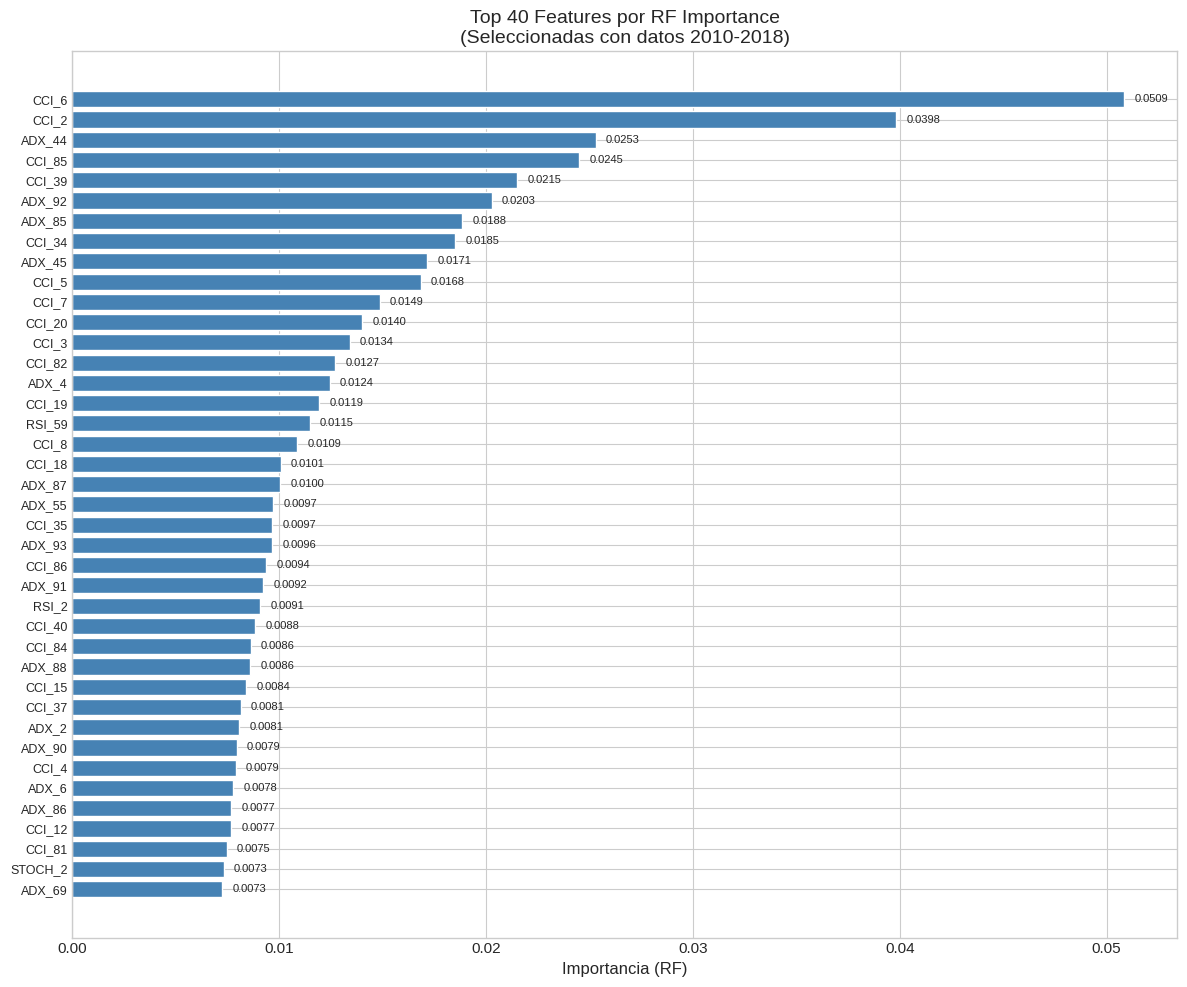

In [ ]:
# ============================================================
# VISUALIZAR IMPORTANCIAS
# ============================================================

fig, ax = plt.subplots(figsize=(12, 10))

# Top 40 features
top_features = importancias.head(N_FEATURES)

# Crear gráfico de barras horizontal
y_pos = range(len(top_features))
bars = ax.barh(y_pos, top_features['Importance'], color='steelblue', edgecolor='white')

# Configurar ejes
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features['Feature'], fontsize=9)
ax.invert_yaxis()  # Mayor importancia arriba
ax.set_xlabel('Importancia (RF)', fontsize=12)
ax.set_title(f'Top {N_FEATURES} Features por RF Importance\n(Seleccionadas con datos 2010-2018)', fontsize=14)

# Añadir valores
for bar, val in zip(bars, top_features['Importance']):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 8. Configuración del Modelo

Usaremos un **Random Forest Classifier** con parámetros fijos para todos los experimentos.

In [ ]:
# ============================================================
# CONFIGURACIÓN DEL MODELO
# ============================================================

# Parámetros del Random Forest Classifier
RF_PARAMS = {
    'n_estimators': 500,    # Número de árboles
    'max_depth': 3,         # Profundidad máxima
    'random_state': 42,     # Reproducibilidad
    'n_jobs': -1            # Usar todos los cores
}

print("=" * 60)
print("CONFIGURACIÓN DEL MODELO")
print("=" * 60)
print(f"\n   Modelo: RandomForestClassifier")
print(f"   Target: Target_Direccion (clasificación binaria)")
print(f"\n   Parámetros:")
for param, valor in RF_PARAMS.items():
    print(f"      • {param}: {valor}")
print(f"\n   Features: {N_FEATURES} seleccionadas por RF Importance")
print("=" * 60)

CONFIGURACIÓN DEL MODELO

   Modelo: RandomForestClassifier
   Target: Target_Direccion (clasificación binaria)

   Parámetros:
      • n_estimators: 500
      • max_depth: 3
      • random_state: 42
      • n_jobs: -1

   Features: 40 seleccionadas por RF Importance


In [ ]:
# ============================================================
# FUNCIÓN PARA ENTRENAR Y EVALUAR
# ============================================================

def entrenar_y_evaluar(df_train, df_test, features, rf_params):
    """
    Entrena un modelo con df_train y evalúa en df_test.

    Retorna:
    - accuracy: Precisión en el conjunto de test
    - equity_curve: Curva de equity en el test (numpy array)
    - predicciones: Array de predicciones
    """
    # Preparar datos de entrenamiento
    X_train = df_train[features]
    y_train = df_train['Target_Direccion']

    # Preparar datos de test
    X_test = df_test[features]
    y_test = df_test['Target_Direccion']
    returns_test = df_test['Target_Return']

    # Entrenar modelo
    modelo = RandomForestClassifier(**rf_params)
    modelo.fit(X_train, y_train)

    # Predecir
    predicciones = modelo.predict(X_test)

    # Calcular accuracy
    accuracy = accuracy_score(y_test, predicciones)

    # Calcular curva de equity
    # Posición: +1 si predice subida, -1 si predice bajada
    posiciones = np.where(predicciones == 1, 1, -1)
    retornos_estrategia = posiciones * returns_test.values
    equity_curve = np.cumprod(1 + retornos_estrategia)

    return {
        'accuracy': accuracy,
        'equity_curve': equity_curve,
        'predicciones': predicciones,
        'fechas': df_test.index
    }

print("✅ Función entrenar_y_evaluar definida")

✅ Función entrenar_y_evaluar definida


---

## 9. EXPERIMENTO 1: ¿Más Histórico = Mejor Modelo?

Vamos a probar la creencia común de que "cuanto más datos históricos, mejor".

```
HIPÓTESIS A CONTRASTAR
═══════════════════════════════════════════════════════════════════

    Creencia popular: "Usa el máximo histórico posible"
    
    Nuestra hipótesis: En mercados financieros, más datos NO siempre
                       significa mejor rendimiento en forward test.
    
    
    Experimento:
    
    Train 2010-2018 (9 años) ─┐
    Train 2011-2018 (8 años) ─┤
    Train 2012-2018 (7 años) ─┤
    Train 2013-2018 (6 años) ─┼───► Test 2019 (Forward)
    Train 2014-2018 (5 años) ─┤
    Train 2015-2018 (4 años) ─┤
    Train 2016-2018 (3 años) ─┘
    
    
    Si la creencia popular es cierta:
        9 años > 8 años > 7 años > ... > 3 años (en accuracy OOS)
    
    Si nuestra hipótesis es cierta:
        No habrá una relación lineal clara
        Posiblemente años intermedios o pocos años funcionen mejor
```

In [ ]:
# ============================================================
# EXPERIMENTO 1: CANTIDAD DE HISTÓRICO
# ============================================================

print("=" * 70)
print("EXPERIMENTO 1: ¿Más histórico = mejor modelo?")
print("=" * 70)
print("\nEntrenando modelos con diferente cantidad de años...")
print("Forward test fijo: 2019\n")

# Años de inicio para cada experimento
años_inicio = [2010, 2011, 2012, 2013, 2014, 2015, 2016]

resultados_exp1 = {}

for año_inicio in años_inicio:
    # Seleccionar datos de entrenamiento
    df_train = df_clean[(df_clean.index.year >= año_inicio) &
                        (df_clean.index.year <= 2018)]

    n_años = 2018 - año_inicio + 1

    print(f"   Train {año_inicio}-2018 ({n_años} años): ", end="")

    # Entrenar y evaluar
    resultado = entrenar_y_evaluar(
        df_train=df_train,
        df_test=df_forward,
        features=features_seleccionadas,
        rf_params=RF_PARAMS
    )

    # Guardar resultado
    clave = f"{año_inicio}-2018 ({n_años}y)"
    resultados_exp1[clave] = {
        'año_inicio': año_inicio,
        'n_años': n_años,
        'n_muestras_train': len(df_train),
        'accuracy': resultado['accuracy'],
        'equity_curve': resultado['equity_curve'],
        'fechas': resultado['fechas']
    }

    equity_final = resultado['equity_curve'][-1]
    print(f"Accuracy: {resultado['accuracy']:.4f}, Equity final: {equity_final:.4f}")

print("\n" + "=" * 70)

EXPERIMENTO 1: ¿Más histórico = mejor modelo?

Entrenando modelos con diferente cantidad de años...
Forward test fijo: 2019

   Train 2010-2018 (9 años): Accuracy: 0.4884, Equity final: 0.9592
   Train 2011-2018 (8 años): Accuracy: 0.5116, Equity final: 1.0059
   Train 2012-2018 (7 años): Accuracy: 0.4806, Equity final: 0.9763
   Train 2013-2018 (6 años): Accuracy: 0.4496, Equity final: 0.9236
   Train 2014-2018 (5 años): Accuracy: 0.4457, Equity final: 0.9145
   Train 2015-2018 (4 años): Accuracy: 0.5039, Equity final: 0.9748
   Train 2016-2018 (3 años): Accuracy: 0.5116, Equity final: 0.9851



In [ ]:
# ============================================================
# TABLA DE RESULTADOS EXPERIMENTO 1
# ============================================================

print("\n" + "=" * 80)
print("RESULTADOS EXPERIMENTO 1: CANTIDAD DE HISTÓRICO")
print("=" * 80)
print(f"\n{'Período Train':<20} {'Años':>6} {'Muestras':>10} {'Accuracy':>10} {'Equity Final':>14} {'Retorno':>10}")
print("-" * 80)

for clave, datos in resultados_exp1.items():
    equity_final = datos['equity_curve'][-1]
    retorno = (equity_final - 1) * 100
    print(f"{clave:<20} {datos['n_años']:>6} {datos['n_muestras_train']:>10,} {datos['accuracy']:>10.4f} {equity_final:>14.4f} {retorno:>9.2f}%")

print("-" * 80)

# Identificar mejor y peor
mejor = max(resultados_exp1.items(), key=lambda x: x[1]['equity_curve'][-1])
peor = min(resultados_exp1.items(), key=lambda x: x[1]['equity_curve'][-1])

print(f"\n🏆 MEJOR:  {mejor[0]} → Equity: {mejor[1]['equity_curve'][-1]:.4f}")
print(f"❌ PEOR:   {peor[0]} → Equity: {peor[1]['equity_curve'][-1]:.4f}")


RESULTADOS EXPERIMENTO 1: CANTIDAD DE HISTÓRICO

Período Train          Años   Muestras   Accuracy   Equity Final    Retorno
--------------------------------------------------------------------------------
2010-2018 (9y)            9      2,231     0.4884         0.9592     -4.08%
2011-2018 (8y)            8      2,072     0.5116         1.0059      0.59%
2012-2018 (7y)            7      1,812     0.4806         0.9763     -2.37%
2013-2018 (6y)            6      1,552     0.4496         0.9236     -7.64%
2014-2018 (5y)            5      1,295     0.4457         0.9145     -8.55%
2015-2018 (4y)            4      1,036     0.5039         0.9748     -2.52%
2016-2018 (3y)            3        777     0.5116         0.9851     -1.49%
--------------------------------------------------------------------------------

🏆 MEJOR:  2011-2018 (8y) → Equity: 1.0059
❌ PEOR:   2014-2018 (5y) → Equity: 0.9145


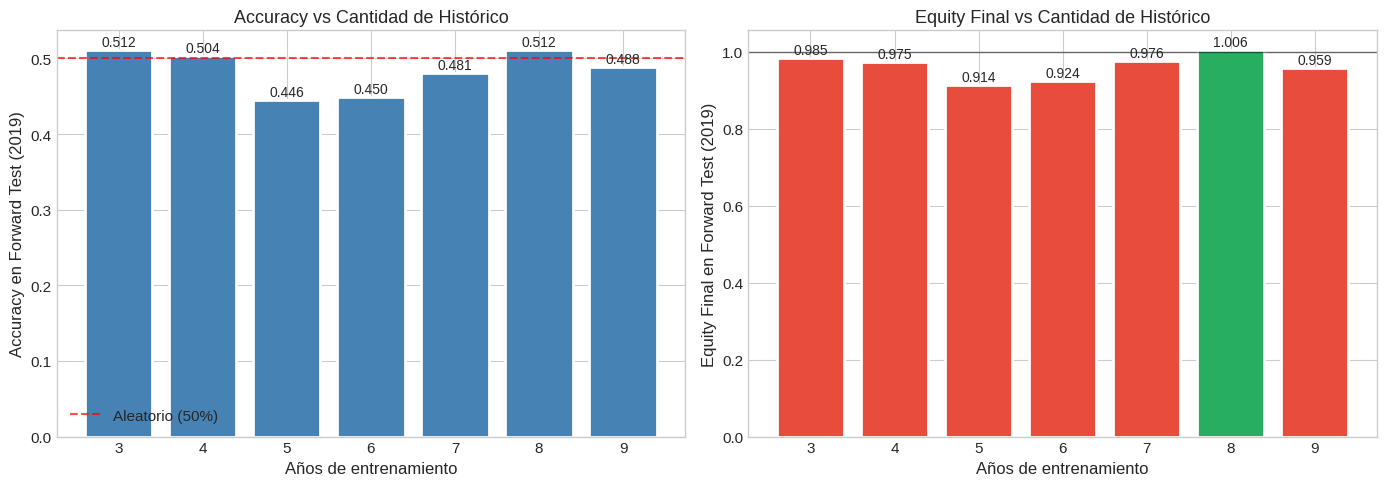

In [ ]:
# ============================================================
# VISUALIZACIÓN: ACCURACY VS CANTIDAD DE AÑOS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Extraer datos para gráficos
n_años_list = [datos['n_años'] for datos in resultados_exp1.values()]
accuracy_list = [datos['accuracy'] for datos in resultados_exp1.values()]
equity_final_list = [datos['equity_curve'][-1] for datos in resultados_exp1.values()]

# Gráfico 1: Accuracy vs Años
ax1 = axes[0]
bars1 = ax1.bar(n_años_list, accuracy_list, color='steelblue', edgecolor='white', linewidth=2)
ax1.set_xlabel('Años de entrenamiento', fontsize=12)
ax1.set_ylabel('Accuracy en Forward Test (2019)', fontsize=12)
ax1.set_title('Accuracy vs Cantidad de Histórico', fontsize=13)
ax1.set_xticks(n_años_list)

# Línea horizontal en 0.5 (aleatorio)
ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Aleatorio (50%)')
ax1.legend()

# Añadir valores sobre barras
for bar, acc in zip(bars1, accuracy_list):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontsize=10)

# Gráfico 2: Equity Final vs Años
ax2 = axes[1]
colors = ['#27ae60' if e > 1 else '#e74c3c' for e in equity_final_list]
bars2 = ax2.bar(n_años_list, equity_final_list, color=colors, edgecolor='white', linewidth=2)
ax2.set_xlabel('Años de entrenamiento', fontsize=12)
ax2.set_ylabel('Equity Final en Forward Test (2019)', fontsize=12)
ax2.set_title('Equity Final vs Cantidad de Histórico', fontsize=13)
ax2.set_xticks(n_años_list)

# Línea horizontal en 1 (capital inicial)
ax2.axhline(y=1, color='black', linestyle='-', alpha=0.5, linewidth=1)

# Añadir valores sobre barras
for bar, eq in zip(bars2, equity_final_list):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{eq:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

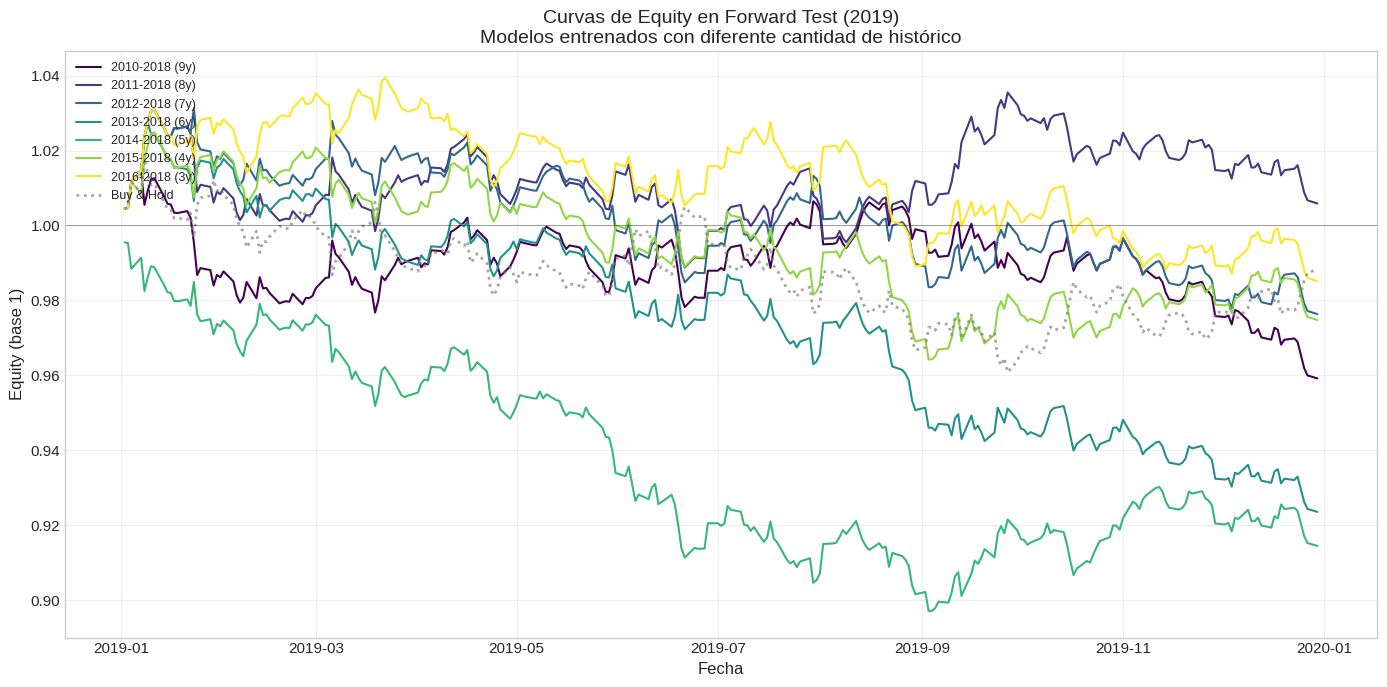

In [ ]:
# ============================================================
# VISUALIZACIÓN: CURVAS DE EQUITY
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

# Paleta de colores
colores = plt.cm.viridis(np.linspace(0, 1, len(resultados_exp1)))

for (clave, datos), color in zip(resultados_exp1.items(), colores):
    ax.plot(datos['fechas'], datos['equity_curve'],
            label=f"{clave}", color=color, linewidth=1.5)

# Buy & Hold
returns_forward = df_forward['Target_Return'].values
equity_bh = np.cumprod(1 + returns_forward)
ax.plot(df_forward.index, equity_bh, label='Buy & Hold',
        color='gray', linestyle=':', linewidth=2, alpha=0.7)

ax.axhline(y=1, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Equity (base 1)', fontsize=12)
ax.set_title('Curvas de Equity en Forward Test (2019)\nModelos entrenados con diferente cantidad de histórico', fontsize=14)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusiones del Experimento 1

```
ANÁLISIS DE RESULTADOS
═══════════════════════════════════════════════════════════════════

    Observaciones:
    
    • NO hay una relación lineal "más años = mejor accuracy"
    • El modelo con MÁS datos (9 años) no es necesariamente el mejor
    • Existe un "punto óptimo" de cantidad de histórico
    
    
    ¿Por qué ocurre esto?
    
    1. CONCEPT DRIFT: Los datos muy antiguos reflejan un mercado
       diferente al actual. Incluirlos puede "confundir" al modelo.
    
    2. SEÑAL VS RUIDO: Más datos no significa más señal.
       Si el mercado ha cambiado, los datos antiguos son ruido.
    
    3. DILUCIÓN DE PATRONES: Los patrones recientes (más relevantes)
       se diluyen entre datos antiguos (menos relevantes).


    LECCIÓN CLAVE:
    ─────────────────────────────────────────────────────────────────
    En mercados financieros, la CALIDAD (relevancia temporal) de los
    datos importa más que la CANTIDAD.
```

---

## 10. EXPERIMENTO 2: ¿Datos Recientes o Lejanos?

Ahora compararemos el efecto de usar datos **cercanos** vs **lejanos** al forward test, manteniendo la misma cantidad de datos.

```
DISEÑO DEL EXPERIMENTO
═══════════════════════════════════════════════════════════════════

    Misma cantidad de datos (3 años), diferente ubicación:
    
    
    DATOS RECIENTES (cerca del forward):
    
    2010   2011   2012   2013   2014   2015   2016   2017   2018   2019
    ─────────────────────────────────────────────────────────────────────
                                             │▓▓▓▓▓▓▓▓▓▓▓▓▓▓│ ░░░░░░░░░
                                             │    TRAIN     │  FORWARD
                                             │  (2016-2018) │   (2019)
                                             │              │
                                             └──────────────┘
                                                    │
                                                    └─► Gap pequeño
    
    
    DATOS LEJANOS (lejos del forward):
    
    2010   2011   2012   2013   2014   2015   2016   2017   2018   2019
    ─────────────────────────────────────────────────────────────────────
                       │▓▓▓▓▓▓▓▓▓▓▓▓▓▓│                       ░░░░░░░░░
                       │    TRAIN     │                        FORWARD
                       │  (2013-2015) │                         (2019)
                       │              │
                       └──────────────┘
                              │
                              └───────────────────────► Gap de 3 años
    
    
    Si el concept drift acumulativo es importante:
        Datos recientes >> Datos lejanos
```

In [ ]:
# ============================================================
# EXPERIMENTO 2: DATOS RECIENTES VS LEJANOS
# ============================================================

print("=" * 70)
print("EXPERIMENTO 2: ¿Datos recientes o lejanos?")
print("=" * 70)
print("\nComparando 3 años de datos en diferente ubicación temporal...")
print("Forward test fijo: 2019\n")

resultados_exp2 = {}

# Configuración de los dos escenarios
escenarios = {
    'RECIENTE (2016-2018)': {'año_inicio': 2016, 'año_fin': 2018},
    'LEJANO (2013-2015)': {'año_inicio': 2013, 'año_fin': 2015}
}

for nombre, config in escenarios.items():
    # Seleccionar datos de entrenamiento
    df_train = df_clean[(df_clean.index.year >= config['año_inicio']) &
                        (df_clean.index.year <= config['año_fin'])]

    print(f"   {nombre}: ", end="")

    # Entrenar y evaluar
    resultado = entrenar_y_evaluar(
        df_train=df_train,
        df_test=df_forward,
        features=features_seleccionadas,
        rf_params=RF_PARAMS
    )

    # Guardar resultado
    resultados_exp2[nombre] = {
        'año_inicio': config['año_inicio'],
        'año_fin': config['año_fin'],
        'n_muestras_train': len(df_train),
        'accuracy': resultado['accuracy'],
        'equity_curve': resultado['equity_curve'],
        'fechas': resultado['fechas']
    }

    equity_final = resultado['equity_curve'][-1]
    print(f"Accuracy: {resultado['accuracy']:.4f}, Equity final: {equity_final:.4f}")

print("\n" + "=" * 70)

EXPERIMENTO 2: ¿Datos recientes o lejanos?

Comparando 3 años de datos en diferente ubicación temporal...
Forward test fijo: 2019

   RECIENTE (2016-2018): Accuracy: 0.5116, Equity final: 0.9851
   LEJANO (2013-2015): Accuracy: 0.4574, Equity final: 0.9617



In [ ]:
# ============================================================
# COMPARACIÓN DETALLADA EXPERIMENTO 2
# ============================================================

print("\n" + "=" * 70)
print("COMPARACIÓN: DATOS RECIENTES VS LEJANOS")
print("=" * 70)

reciente = resultados_exp2['RECIENTE (2016-2018)']
lejano = resultados_exp2['LEJANO (2013-2015)']

print(f"\n{'Métrica':<25} {'Reciente (2016-18)':>20} {'Lejano (2013-15)':>20} {'Diferencia':>15}")
print("-" * 80)

# Accuracy
diff_acc = reciente['accuracy'] - lejano['accuracy']
print(f"{'Accuracy':<25} {reciente['accuracy']:>20.4f} {lejano['accuracy']:>20.4f} {diff_acc:>+15.4f}")

# Equity final
eq_rec = reciente['equity_curve'][-1]
eq_lej = lejano['equity_curve'][-1]
diff_eq = eq_rec - eq_lej
print(f"{'Equity Final':<25} {eq_rec:>20.4f} {eq_lej:>20.4f} {diff_eq:>+15.4f}")

# Retorno
ret_rec = (eq_rec - 1) * 100
ret_lej = (eq_lej - 1) * 100
diff_ret = ret_rec - ret_lej
print(f"{'Retorno (%)':<25} {ret_rec:>19.2f}% {ret_lej:>19.2f}% {diff_ret:>+14.2f}%")

# Muestras de entrenamiento
print(f"{'Muestras Train':<25} {reciente['n_muestras_train']:>20,} {lejano['n_muestras_train']:>20,}")

print("-" * 80)

# Determinar ganador
if eq_rec > eq_lej:
    ganador = "RECIENTE"
    ventaja = ((eq_rec / eq_lej) - 1) * 100 if eq_lej > 0 else float('inf')
else:
    ganador = "LEJANO"
    ventaja = ((eq_lej / eq_rec) - 1) * 100 if eq_rec > 0 else float('inf')

print(f"\n🏆 GANADOR: {ganador} (ventaja relativa: {ventaja:.1f}%)")


COMPARACIÓN: DATOS RECIENTES VS LEJANOS

Métrica                     Reciente (2016-18)     Lejano (2013-15)      Diferencia
--------------------------------------------------------------------------------
Accuracy                                0.5116               0.4574         +0.0543
Equity Final                            0.9851               0.9617         +0.0234
Retorno (%)                             -1.49%               -3.83%          +2.34%
Muestras Train                             777                  775
--------------------------------------------------------------------------------

🏆 GANADOR: RECIENTE (ventaja relativa: 2.4%)


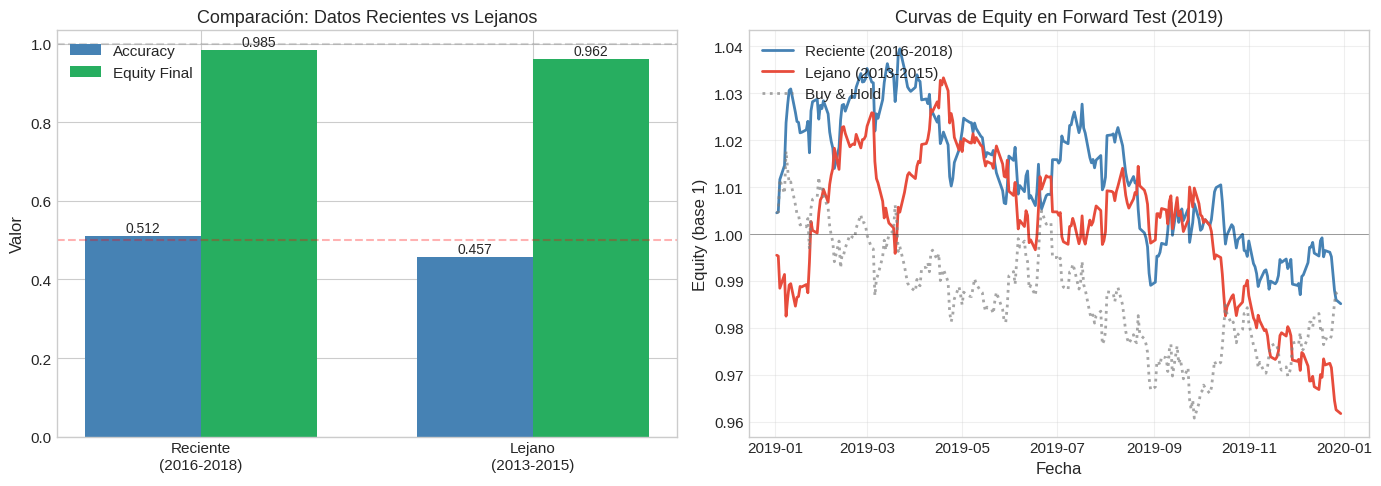

In [ ]:
# ============================================================
# VISUALIZACIÓN EXPERIMENTO 2
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Barras comparativas
ax1 = axes[0]
nombres = ['Reciente\n(2016-2018)', 'Lejano\n(2013-2015)']
accuracies = [reciente['accuracy'], lejano['accuracy']]
equities = [eq_rec, eq_lej]

x = np.arange(len(nombres))
width = 0.35

bars1 = ax1.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax1.bar(x + width/2, equities, width, label='Equity Final', color='#27ae60')

ax1.set_ylabel('Valor', fontsize=12)
ax1.set_title('Comparación: Datos Recientes vs Lejanos', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels(nombres)
ax1.legend()
ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.3, label='Aleatorio')
ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

# Añadir valores
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontsize=10)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontsize=10)

# Gráfico 2: Curvas de equity
ax2 = axes[1]

ax2.plot(reciente['fechas'], reciente['equity_curve'],
         label='Reciente (2016-2018)', color='steelblue', linewidth=2)
ax2.plot(lejano['fechas'], lejano['equity_curve'],
         label='Lejano (2013-2015)', color='#e74c3c', linewidth=2)
ax2.plot(df_forward.index, equity_bh, label='Buy & Hold',
         color='gray', linestyle=':', linewidth=2, alpha=0.7)

ax2.axhline(y=1, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.set_xlabel('Fecha', fontsize=12)
ax2.set_ylabel('Equity (base 1)', fontsize=12)
ax2.set_title('Curvas de Equity en Forward Test (2019)', fontsize=13)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusiones del Experimento 2

```
ANÁLISIS DE RESULTADOS
═══════════════════════════════════════════════════════════════════

    Con la MISMA cantidad de datos (3 años):
    
    • Los datos RECIENTES funcionan mejor que los LEJANOS
    • La diferencia puede ser muy significativa
    
    
    ¿Por qué?
    
    ┌─────────────────────────────────────────────────────────────┐
    │                  CONCEPT DRIFT ACUMULATIVO                  │
    └─────────────────────────────────────────────────────────────┘
    
    2013 ──────────────────────────────────────────────────► 2019
    
    │    Lejano     │         Gap          │   Test   │
    │  (2013-2015)  │      (3 años)        │  (2019)  │
    │               │                      │          │
    └───────────────┴──────────────────────┴──────────┘
    
    Datos 2013-2015:  ═══════════════════════►  Drift de 3 años hasta 2019
    Datos 2016-2018:                  ════════►  Sin gap hasta 2019
    
    
    IMPLICACIÓN PARA train_test_split:
    ─────────────────────────────────────────────────────────────────
    
    El split tradicional (primero train, luego test) hace EXACTAMENTE
    lo contrario de lo óptimo: pone los datos más antiguos en train.
    
    Para trading, es mejor:
    1. Entrenar con datos RECIENTES
    2. Minimizar el gap entre train y forward real
```

---

## 11. Comparación: Métricas IS vs OOS

Finalmente, veamos la diferencia entre evaluar en datos de entrenamiento (IS) vs datos nuevos (OOS).

In [ ]:
# ============================================================
# COMPARACIÓN IS vs OOS
# Entrenar con 2016-2018, comparar métricas IS vs OOS (2019)
# ============================================================

print("=" * 70)
print("COMPARACIÓN: MÉTRICAS IN-SAMPLE VS OUT-OF-SAMPLE")
print("=" * 70)

# Usar el modelo con datos recientes (2016-2018)
df_train_is = df_clean[(df_clean.index.year >= 2016) &
                       (df_clean.index.year <= 2018)]

# Preparar datos
X_train = df_train_is[features_seleccionadas]
y_train = df_train_is['Target_Direccion']
returns_train = df_train_is['Target_Return'].values

X_test = df_forward[features_seleccionadas]
y_test = df_forward['Target_Direccion']
returns_test = df_forward['Target_Return'].values

# Entrenar modelo
modelo_final = RandomForestClassifier(**RF_PARAMS)
modelo_final.fit(X_train, y_train)

# Predicciones IS (en datos de entrenamiento)
pred_is = modelo_final.predict(X_train)
accuracy_is = accuracy_score(y_train, pred_is)

# Predicciones OOS (en forward test)
pred_oos = modelo_final.predict(X_test)
accuracy_oos = accuracy_score(y_test, pred_oos)

# Equity curves
pos_is = np.where(pred_is == 1, 1, -1)
ret_estrategia_is = pos_is * returns_train
equity_is = np.cumprod(1 + ret_estrategia_is)

pos_oos = np.where(pred_oos == 1, 1, -1)
ret_estrategia_oos = pos_oos * returns_test
equity_oos = np.cumprod(1 + ret_estrategia_oos)

print(f"\n{'Métrica':<25} {'IN-SAMPLE':>20} {'OUT-OF-SAMPLE':>20} {'Diferencia':>15}")
print(f"{'(Train: 2016-2018)':<25} {'(2016-2018)':>20} {'(2019)':>20}")
print("-" * 80)

diff_acc = accuracy_is - accuracy_oos
print(f"{'Accuracy':<25} {accuracy_is:>20.4f} {accuracy_oos:>20.4f} {diff_acc:>+15.4f}")

eq_is_final = equity_is[-1]
eq_oos_final = equity_oos[-1]
diff_eq = eq_is_final - eq_oos_final
print(f"{'Equity Final':<25} {eq_is_final:>20.4f} {eq_oos_final:>20.4f} {diff_eq:>+15.4f}")

ret_is = (eq_is_final - 1) * 100
ret_oos = (eq_oos_final - 1) * 100
diff_ret = ret_is - ret_oos
print(f"{'Retorno (%)':<25} {ret_is:>19.2f}% {ret_oos:>19.2f}% {diff_ret:>+14.2f}%")

print("-" * 80)
print(f"\n⚠️  La caída IS → OOS es la REALIDAD de lo que esperamos en trading real")

COMPARACIÓN: MÉTRICAS IN-SAMPLE VS OUT-OF-SAMPLE

Métrica                              IN-SAMPLE        OUT-OF-SAMPLE      Diferencia
(Train: 2016-2018)                 (2016-2018)               (2019)
--------------------------------------------------------------------------------
Accuracy                                0.6937               0.5116         +0.1821
Equity Final                            3.0379               0.9851         +2.0528
Retorno (%)                            203.79%               -1.49%        +205.28%
--------------------------------------------------------------------------------

⚠️  La caída IS → OOS es la REALIDAD de lo que esperamos en trading real


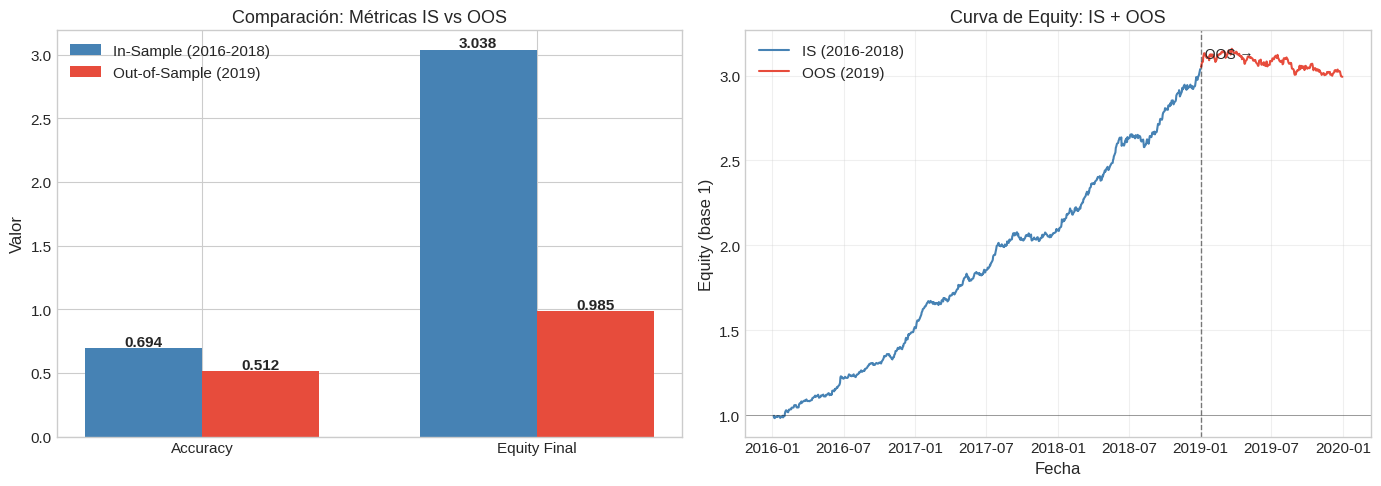

In [ ]:
# ============================================================
# VISUALIZACIÓN IS vs OOS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Barras comparativas
ax1 = axes[0]
categorias = ['Accuracy', 'Equity Final']
valores_is = [accuracy_is, eq_is_final]
valores_oos = [accuracy_oos, eq_oos_final]

x = np.arange(len(categorias))
width = 0.35

bars1 = ax1.bar(x - width/2, valores_is, width, label='In-Sample (2016-2018)', color='steelblue')
bars2 = ax1.bar(x + width/2, valores_oos, width, label='Out-of-Sample (2019)', color='#e74c3c')

ax1.set_ylabel('Valor', fontsize=12)
ax1.set_title('Comparación: Métricas IS vs OOS', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels(categorias)
ax1.legend()

# Añadir valores
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.3f}', ha='center', fontsize=11, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.3f}', ha='center', fontsize=11, fontweight='bold')

# Gráfico 2: Curvas de equity concatenadas
ax2 = axes[1]

# IS
ax2.plot(df_train_is.index, equity_is, color='steelblue', linewidth=1.5, label='IS (2016-2018)')

# OOS (ajustar para que empiece donde termina IS)
equity_oos_ajustado = equity_oos * eq_is_final
ax2.plot(df_forward.index, equity_oos_ajustado, color='#e74c3c', linewidth=1.5, label='OOS (2019)')

# Línea vertical separadora
ax2.axvline(x=df_forward.index[0], color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.text(df_forward.index[0], ax2.get_ylim()[1]*0.95, ' OOS →', fontsize=10)

ax2.axhline(y=1, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.set_xlabel('Fecha', fontsize=12)
ax2.set_ylabel('Equity (base 1)', fontsize=12)
ax2.set_title('Curva de Equity: IS + OOS', fontsize=13)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## ⚠️ La Brecha IS-OOS: Señal de Alerta

```
¿QUÉ NOS DICE LA DIFERENCIA IS vs OOS?
═══════════════════════════════════════════════════════════════════

    IS >> OOS  →  El modelo ha SOBREAJUSTADO
    
    El modelo ha "memorizado" patrones específicos del período
    de entrenamiento que no se generalizan al futuro.
    
    
    REGLA PRÁCTICA:
    ───────────────
    
    • Si Accuracy IS ≈ Accuracy OOS → Modelo generaliza bien
    • Si Accuracy IS >> Accuracy OOS → Sobreajuste
    • Si Accuracy IS < Accuracy OOS → Algo raro (revisar datos)
    
    
    EN TRADING:
    ───────────
    
    Las métricas IS son FANTASÍA.
    Las métricas OOS son tu MEJOR ESTIMACIÓN de la realidad.
    
    Nunca confíes en un backtest que solo muestra resultados IS.
```

---

## Resumen de la Sesión

En esta sesión hemos aprendido:

✅ **Partición IS/OOS:** Fundamental para evaluación honesta

✅ **División temporal:** En series financieras, NUNCA mezclar pasado con futuro

✅ **Mito 1 derribado:** Más histórico NO siempre significa mejor modelo

✅ **Mito 2 derribado:** Datos recientes funcionan mejor que datos lejanos

✅ **Concept drift:** Los mercados cambian, los modelos "envejecen"

✅ **Brecha IS-OOS:** Indicador de sobreajuste

```
LECCIONES CLAVE PARA TRADING
═══════════════════════════════════════════════════════════════════

    1. SIEMPRE evalúa en datos OOS (forward test)
    
    2. Entrena con datos RECIENTES, no con todo el histórico
    
    3. Minimiza el gap entre fin de train y aplicación real
    
    4. Desconfía de resultados IS espectaculares
    
    5. El rendimiento OOS es tu mejor estimación del futuro
```

### Próxima Sesión

En la **Sesión 9 (5 de febrero)** veremos **Sobreoptimización**, donde aprenderemos:

- **Overfitting de hiperparámetros:** Cómo elegir parámetros "contamina" el OOS
- **Múltiples comparaciones:** El peligro de probar muchas configuraciones
- **Soluciones prácticas:** Validación, regularización, simplicidad

Esto complementará lo aprendido hoy sobre partición IS/OOS.

---

### 📝 Nota: Cross Validation

Existe una técnica llamada **Cross Validation** que permite hacer múltiples particiones IS/OOS de forma sistemática. En series temporales, se debe usar `TimeSeriesSplit` en lugar del K-Fold tradicional para respetar el orden cronológico.

Veremos esta técnica en detalle en la **Sesión 10 (Optimización)** cuando trabajemos con `GridSearchCV` para búsqueda de hiperparámetros.